In [1]:
pip install pandas scikit-learn matplotlib tensorflow rasterio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 58.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import matplotlib.pyplot as plt


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Replace the path with the actual path to your CSV in Drive
df = pd.read_csv('/content/drive/MyDrive/GEEE/Hyderabad_Training_Data.csv')
df = df.dropna()
df.head()


,system:index,B2,B3,B4,B8,class,.geo
0,1_1_0_0,2266.0,2526.0,2706.0,3016.0,0,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1_1_1_0,1654.0,1986.0,2148.0,2409.0,0,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,1_1_2_0,1248.0,1498.0,1658.0,2253.0,0,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,1_1_3_0,1246.0,1378.0,1556.0,1911.0,0,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,1_1_4_0,2160.0,2504.0,2712.0,3051.0,0,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [5]:
features = ['B2', 'B3', 'B4', 'B8']  # Blue, Green, Red, NIR
X = df[features]
y = df['class']  # Make sure it's the exact column name from GEE

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.4621 - loss: 1.0681 - val_accuracy: 0.8224 - val_loss: 0.7478
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7835 - loss: 0.7870 - val_accuracy: 0.8972 - val_loss: 0.5698
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8232 - loss: 0.6536 - val_accuracy: 0.9065 - val_loss: 0.4662
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8325 - loss: 0.5517 - val_accuracy: 0.9065 - val_loss: 0.3932
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8483 - loss: 0.4621 - val_accuracy: 0.9065 - val_loss: 0.3382
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8194 - loss: 0.4371 - val_accuracy: 0.9159 - val_loss: 0.2985
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8411 - loss: 0.3830 - val_accuracy: 0.9252 - val_loss: 0.2655
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8469 - loss: 0.3463 - val_accuracy: 0.9252 - val_loss: 0.2462
Ep

In [7]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[47  0  0]
 [ 0 28  2]
 [ 0  3 27]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       0.90      0.93      0.92        30
           2       0.93      0.90      0.92        30

    accuracy                           0.95       107
   macro avg       0.94      0.94      0.94       107
weighted avg       0.95      0.95      0.95       107



In [8]:
# Predict all pixels
pred_all = model.predict(X)
df['predicted_class'] = pred_all.argmax(axis=1)

# Save results
df.to_csv('/content/drive/MyDrive/Hyderabad_ANN_Predictions.csv', index=False)
print("Predictions saved to Google Drive.")


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Predictions saved to Google Drive.


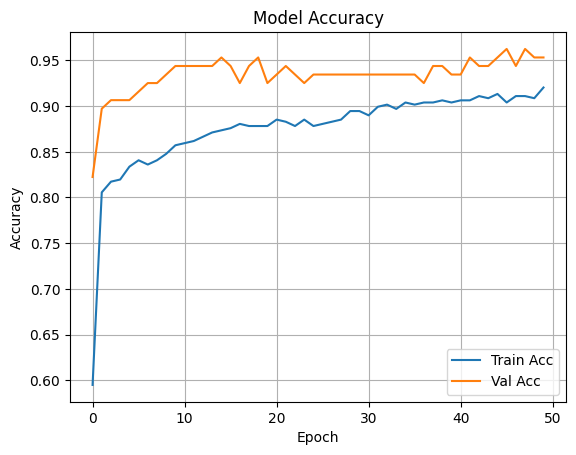

In [9]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
model.save("hyderabad_landcover_ann_model.h5")


In [11]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/hyderabad_landcover_ann_model.h5 /content/drive/MyDrive/


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!ls /content/drive/MyDrive/


 Budida_Uday_Kiran.pdf		 Hyderabad_ANN_Predictions.csv
'Budida Uday Kiran Resume.tex'	 hyderabad_landcover_ann_model.h5
'Colab Notebooks'		 Hyderabad_Landcover_Classification.tif
 GEEE


In [13]:
import numpy as np
import rasterio
from tensorflow.keras.models import load_model
model = load_model('/content/hyderabad_landcover_ann_model.h5')
predicted = model.predict(X_test)
with rasterio.open(
    '/content/hyderabad_classified.tif',
    'w',
    driver='GTiff',
    height=predicted.shape[0],
    width=predicted.shape[1],
    count=1,
    dtype='uint8'
) as dst:
    dst.write(predicted.astype('uint8'), 1)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = writer(
